In [30]:
pip install tensorflow keras numpy pandas matplotlib opencv-python scikit-learn flask flask-cors


In [31]:
import numpy as np
import pandas as pd
import os
import cv2
import json
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [32]:
# Load dataset
file_path = '/content/drive/MyDrive/MachineLearning/data.csv'
df = pd.read_csv(file_path)

In [33]:
# Separate features (pixels) and labels (characters)
X = df.drop('character', axis=1).values
y = df['character'].values

In [34]:
# Reshape pixel data into images (32x32) and normalize
X = X.reshape(-1, 32, 32, 1) / 255.0

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

In [35]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)

print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")
print(f"Classes: {label_encoder.classes_}")
class_names = list(label_encoder.classes_)
print(class_names)

Train set: (73600, 32, 32, 1), Test set: (18400, 32, 32, 1)
Classes: ['character_01_ka' 'character_02_kha' 'character_03_ga' 'character_04_gha'
 'character_05_kna' 'character_06_cha' 'character_07_chha'
 'character_08_ja' 'character_09_jha' 'character_10_yna'
 'character_11_taamatar' 'character_12_thaa' 'character_13_daa'
 'character_14_dhaa' 'character_15_adna' 'character_16_tabala'
 'character_17_tha' 'character_18_da' 'character_19_dha' 'character_20_na'
 'character_21_pa' 'character_22_pha' 'character_23_ba' 'character_24_bha'
 'character_25_ma' 'character_26_yaw' 'character_27_ra' 'character_28_la'
 'character_29_waw' 'character_30_motosaw' 'character_31_petchiryakha'
 'character_32_patalosaw' 'character_33_ha' 'character_34_chhya'
 'character_35_tra' 'character_36_gya' 'digit_0' 'digit_1' 'digit_2'
 'digit_3' 'digit_4' 'digit_5' 'digit_6' 'digit_7' 'digit_8' 'digit_9']
['character_01_ka', 'character_02_kha', 'character_03_ga', 'character_04_gha', 'character_05_kna', 'character_06

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# CNN Model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 1)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(len(np.unique(y_encoded)), activation='softmax')
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 46)             │        23,598 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 379,822 (1.45 MB)

 Trainable params: 379,374 (1.45 MB)

 Non-trainable params: 448 (1.75 KB)

In [37]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.2,
    zoom_range=0.2
)

# Train the model
history = model.fit(datagen.flow(X_train, y_train, batch_size=64),
                    validation_data=(X_test, y_test),
                    epochs=2)




Epoch 1/2
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 196s 167ms/step - accuracy: 0.7092 - loss: 1.0048 - val_accuracy: 0.9436 - val_loss: 0.1808
Epoch 2/2
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 192s 167ms/step - accuracy: 0.8837 - loss: 0.3775 - val_accuracy: 0.9679 - val_loss: 0.1041


In [38]:
# Save the model
model.save('/content/drive/MyDrive/MachineLearning/devanagari_cnn_model.keras')

model.save_weights('/content/drive/MyDrive/MachineLearning/devanagari_cnn_weights.weights.h5')
label_map = {i: label for i, label in enumerate(class_names)}

with open("/content/drive/MyDrive/MachineLearning/label_map.json", "w", encoding="utf-8") as f:
    json.dump(label_map, f, ensure_ascii=False, indent=2)

575/575 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step
                           precision    recall  f1-score   support

          character_01_ka       0.96      1.00      0.98       380
         character_02_kha       0.99      0.99      0.99       404
          character_03_ga       0.99      0.98      0.99       371
         character_04_gha       0.89      0.98      0.93       404
         character_05_kna       1.00      0.97      0.98       423
         character_06_cha       0.97      0.99      0.98       394
        character_07_chha       0.98      0.96      0.97       395
          character_08_ja       0.99      0.99      0.99       384
         character_09_jha       1.00      0.99      0.99       401
         character_10_yna       0.98      0.98      0.98       388
    character_11_taamatar       0.98      0.97      0.98       426
        character_12_thaa       0.98      0.98      0.98       382
         character_13_daa       0.96      0.99      0.97       421
        character_

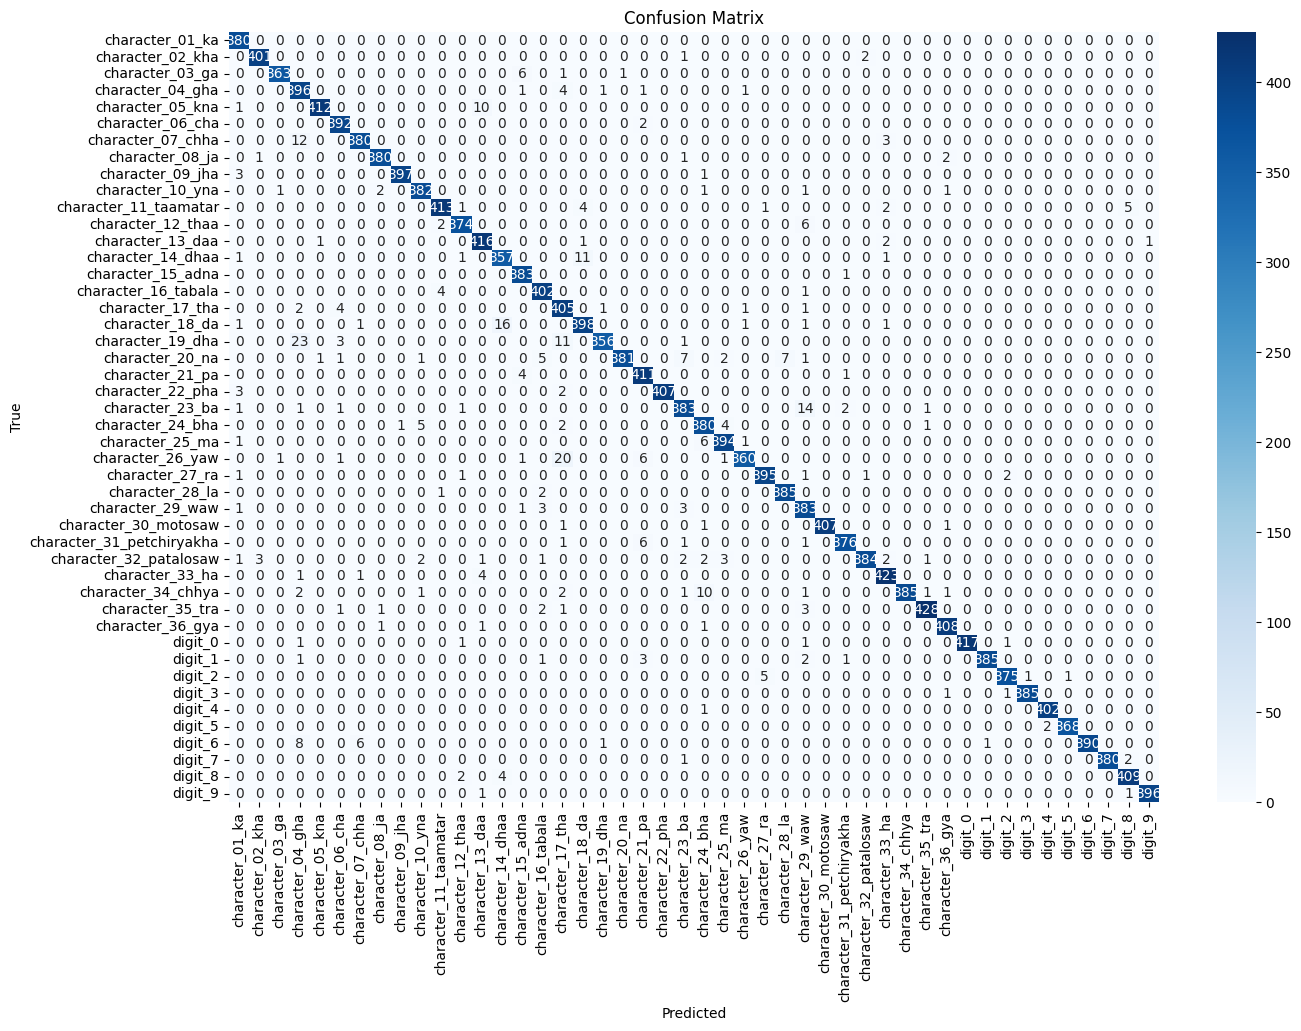

In [43]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Evaluate model
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Generate classification report
report = classification_report(y_true_classes, y_pred_classes, target_names=label_encoder.classes_)
print(report)

# Confusion Matrix Visualization
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(15, 10))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [49]:
import numpy as np
import cv2
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import os

# Load the trained model
model_path = '/content/drive/MyDrive/MachineLearning/devanagari_cnn_model.keras'
model = load_model(model_path)

# Character classes (replace with actual class names)
class_labels = ['क', 'ख', 'ग', 'घ', 'ङ', 'च', 'छ', 'ज', 'झ', 'ञ',
                'ट', 'ठ', 'ड', 'ढ', 'ण', 'त', 'थ', 'द', 'ध', 'न',
                'प', 'फ', 'ब', 'भ', 'म', 'य', 'र', 'ल', 'व', 'श',
                'ष', 'स', 'ह', 'क्ष', 'त्र', 'ज्ञ']  # Update if needed

def predict_character(image_path):
    """Predict the Devanagari character from the given image path."""
    if not os.path.exists(image_path):
        print("Error: File does not exist.")
        return

    # Check file extension
    if image_path.split('.')[-1].lower() not in ['jpg', 'jpeg', 'png']:
        print("Error: Invalid file format. Use JPG, JPEG, or PNG.")
        return

    # Load and preprocess the image
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("Error: Could not read the image file.")
        return

    # Convert image to black and white
    _, img_bw = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    # Invert the image
    img_inverted = cv2.bitwise_not(img_bw)

    img_resized = cv2.resize(img_inverted, (32, 32))  # Resize to model input size
    img_normalized = img_resized / 255.0  # Normalize pixel values
    img_final = img_normalized.reshape(1, 32, 32, 1)

    # Display the processed image
   # cv2.imshow("Processed Image", img_inverted)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

    # Predict the character
    prediction = model.predict(img_final)
    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction)

    # Map prediction to class label
    predicted_character = class_labels[predicted_class] if predicted_class < len(class_labels) else "Unknown"

    # Display result
    print(f"Predicted Character: {predicted_character}")
    print(f"Confidence: {confidence:.2%}")

In [61]:
# Provide the file path here
file_path = '/content/drive/MyDrive/MachineLearning/test/tr.jpg'
predict_character(file_path)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted Character: च
Confidence: 25.92%
